# 01 - Explore the data: what is Customer Value Optimization?

**CVO in one paragraph.** In a subscription / e-commerce business, not all customers are worth the same.

CVO is the set of ML-driven decisions that estimate *how much value a customer will bring in the future*
(spend, retention, churn risk) and then act on it: who gets a discount, which offer, which reactivation email,
how much to spend to acquire or keep them.

**Our toy version.** Pick a cutoff date. Using only history *before* the cutoff, predict each customer's
**spend in the next 90 days**. That single number (a CLV-style score) is what a downstream system would consume.

**Dataset.** UCI Online Retail II (UK gift retailer, Dec 2009 - Dec 2011, CC BY 4.0).
Not groceries, but it has what a CVO model needs: customer ids, timestamps, order values, returns.

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.width", 140)

df = pd.read_parquet("../data/processed/transactions.parquet")
print(df.shape)
df.head()

(1067371, 8)


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.drop_duplicates(subset=['customer_id']).head(5)["customer_id"]

0     13085.0
12    13078.0
31    15362.0
54    18102.0
71    12682.0
Name: customer_id, dtype: float64

## 1. Data quality

In [2]:
print(df.dtypes, "\n")
print("Missing values:\n", df.isna().mean().round(3), "\n")
print("Date range:", df.invoice_date.min(), "->", df.invoice_date.max())
print("Customers:", df.customer_id.nunique())
print("Cancelled invoices (start with 'C'):", df.invoice.str.startswith("C").mean().round(3))
print("Rows with quantity<=0:", (df.quantity <= 0).mean().round(3), "| price<=0:", (df.price <= 0).mean().round(3))

invoice                    str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
price                  float64
customer_id            float64
country                    str
dtype: object 

Missing values:
 invoice         0.000
stock_code      0.000
description     0.004
quantity        0.000
invoice_date    0.000
price           0.000
customer_id     0.228
country         0.000
dtype: float64 

Date range: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Customers: 5942
Cancelled invoices (start with 'C'): 0.018
Rows with quantity<=0: 0.022 | price<=0: 0.006


**Cleaning decisions (write down why - interviewers like this):**
- Rows with no `customer_id` cannot be tied to a customer -> drop (about a fifth of rows in the full data).
- Invoices starting with `C` are returns/cancellations: keep them for a *return rate* feature, but exclude from revenue.
- Price <= 0 rows are adjustments/samples -> drop.

In [3]:
d = df.dropna(subset=["customer_id"]).copy()
d["customer_id"] = d["customer_id"].astype(int)
d["is_return"] = d.invoice.str.startswith("C")
d = d[d.price > 0]
d["line_value"] = d.quantity * d.price
sales = d[~d.is_return & (d.quantity > 0)]
print("Clean rows:", len(d), "| sales rows:", len(sales))

Clean rows: 824293 | sales rows: 805549


## 2. Customer-level shape (this is where CVO lives)

       orders   revenue                       first                        last
count  5878.0    5878.0                        5878                        5878
mean      6.3    3018.6  2010-08-22 06:57:33.297039  2011-05-22 16:19:59.469207
min       1.0       3.0         2009-12-01 07:45:00         2009-12-01 09:55:00
25%       1.0     348.8         2010-02-09 14:01:15         2010-11-25 10:24:45
50%       3.0     898.9         2010-06-27 13:31:30         2011-09-05 11:59:00
75%       7.0    2307.1         2011-01-30 14:30:15         2011-11-14 11:31:15
max     398.0  608821.6         2011-12-09 12:16:00         2011-12-09 12:50:00
std      13.0   14737.7                         NaN                         NaN


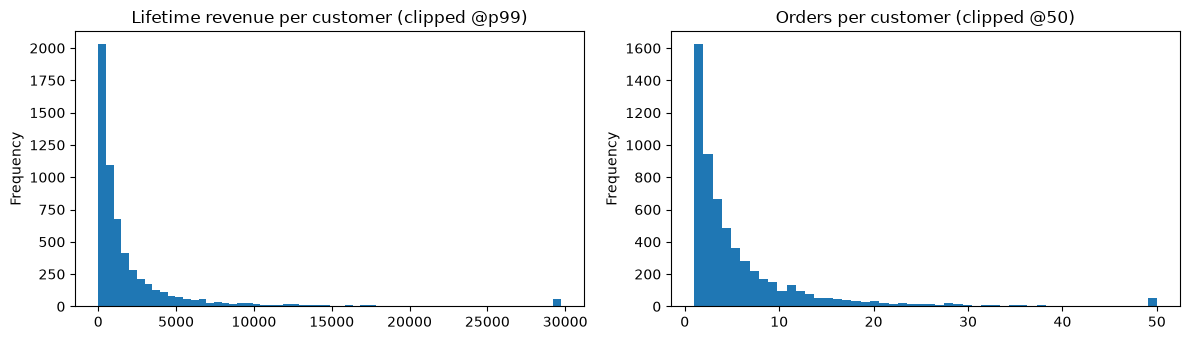

In [4]:
cust = sales.groupby("customer_id").agg(
    orders=("invoice", "nunique"),
    revenue=("line_value", "sum"),
    first=("invoice_date", "min"),
    last=("invoice_date", "max"),
)
print(cust.describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
cust.revenue.clip(upper=cust.revenue.quantile(.99)).plot.hist(bins=60, ax=ax[0], title="Lifetime revenue per customer (clipped @p99)")
cust.orders.clip(upper=50).plot.hist(bins=50, ax=ax[1], title="Orders per customer (clipped @50)")
plt.tight_layout()

In [5]:
# Pareto check: how concentrated is value?
s = cust.revenue.sort_values(ascending=False)
top20 = s.head(int(len(s) * .2)).sum() / s.sum()
print(f"Top 20% of customers = {top20:.0%} of revenue")

Top 20% of customers = 77% of revenue


## 3. Monthly activity (check seasonality before choosing a cutoff)

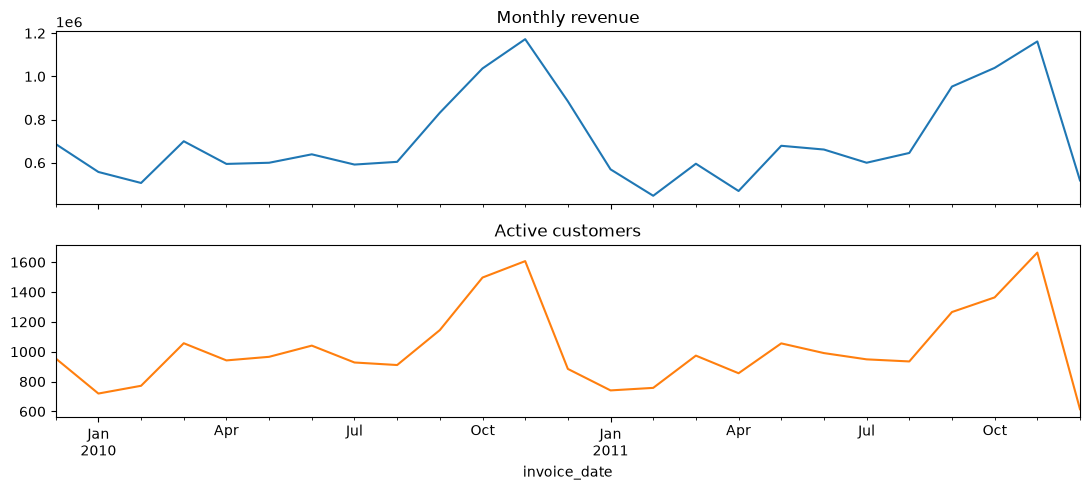

In [6]:
m = sales.set_index("invoice_date").resample("MS").agg(revenue=("line_value", "sum"), customers=("customer_id", "nunique"))
m.plot(subplots=True, figsize=(11, 5), title=["Monthly revenue", "Active customers"], legend=False)
plt.tight_layout()

## 4. Define the prediction problem (preview)

- **Cutoff** `T` (we use `2011-09-09`, leaving 90 days of future data before the dataset ends on 2011-12-09).
- **Features**: computed from transactions with `invoice_date < T` only (no leakage).
- **Target**: total sales value in `[T, T + 90d)`. Customers with no purchase get 0.
- **Population**: customers who purchased at least once before `T`.

Zero-inflated, heavy-tailed target -> we will model `log1p(target)` and report MAE/RMSE on both scales, plus
a rank-based metric (Spearman) because CVO often uses the score to *rank* customers.

Population: 5278 | bought in next 90d: 43%
count      5278.0
mean        539.2
std        3199.8
min           0.0
25%           0.0
50%           0.0
75%         437.3
max      112721.0
Name: line_value, dtype: float64


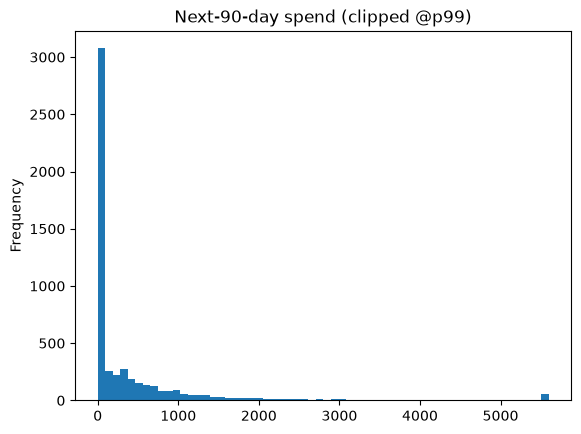

In [7]:
T = pd.Timestamp("2011-09-09"); H = pd.Timedelta(days=90)
hist = sales[sales.invoice_date < T]
fut  = sales[(sales.invoice_date >= T) & (sales.invoice_date < T + H)]
pop = hist.customer_id.unique()
y = fut.groupby("customer_id").line_value.sum().reindex(pop).fillna(0)
print("Population:", len(pop), "| bought in next 90d:", f"{(y>0).mean():.0%}")
print(y.describe().round(1))
y.clip(upper=y.quantile(.99)).plot.hist(bins=60, title="Next-90-day spend (clipped @p99)");

## 5. Questions to answer before notebook 02 (features)
1. Which RFM-style features (recency, frequency, monetary) separate buyers from non-buyers?
2. Does tenure or return rate add signal?
3. What happens if we pick a different cutoff (e.g. 2011-06-09)? Is the model stable?

**Next:** `02_features_and_model.ipynb`.